In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

<Axes: >

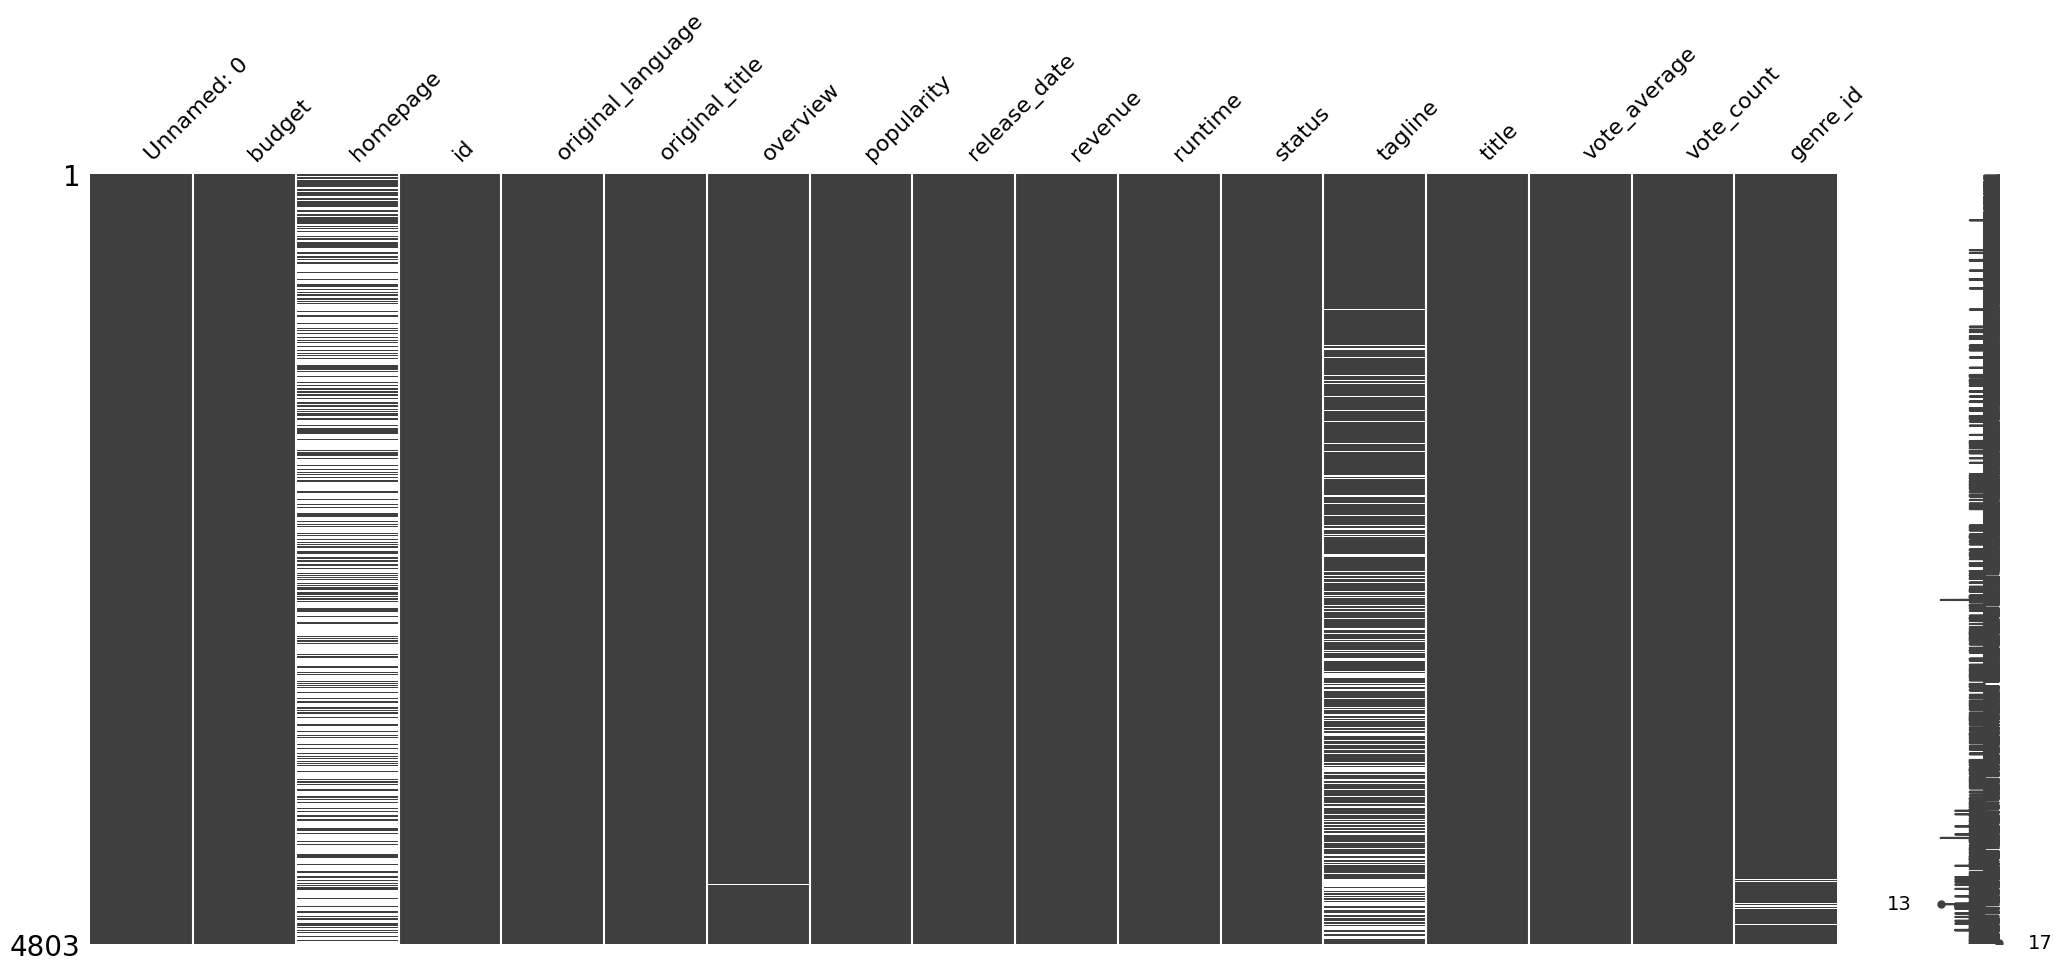

In [43]:
movies_df = pd.read_csv('tmdb_movies.csv')
msno.matrix(movies_df)

In [53]:
genres_df = pd.read_csv('tmdb_genres.csv')


In [57]:
top_rated_movies = movies_df[movies_df['vote_count'] >= movies_df['vote_count'].quantile(0.75)]
top_rated_movies = top_rated_movies.sort_values(by='vote_average', ascending=False)


In [71]:
ad_2_df = movies_df.copy()
ad_2_df['release_date'] = pd.to_datetime(ad_2_df['release_date'])
ad_2_df = ad_2_df[ad_2_df['release_date'].dt.year.between(2010, 2016)]
ad_2_df['release_date'] = ad_2_df['release_date'].dt.year

In [80]:
ad_2_df = ad_2_df.pivot_table(values=['revenue','budget'],index='release_date',aggfunc=np.mean)

In [81]:
ad_2_df

,budget,revenue
release_date,,
2010,3.449541e+07,9.043811e+07
2011,3.477232e+07,9.200413e+07
2012,3.492203e+07,1.160659e+08
2013,3.552329e+07,1.013485e+08
2014,3.095989e+07,1.013466e+08
2015,3.113216e+07,1.054399e+08
2016,4.570327e+07,1.390496e+08


In [90]:
def million(x, pos):
        return '{:2.1f}M'.format(x*1e-6)

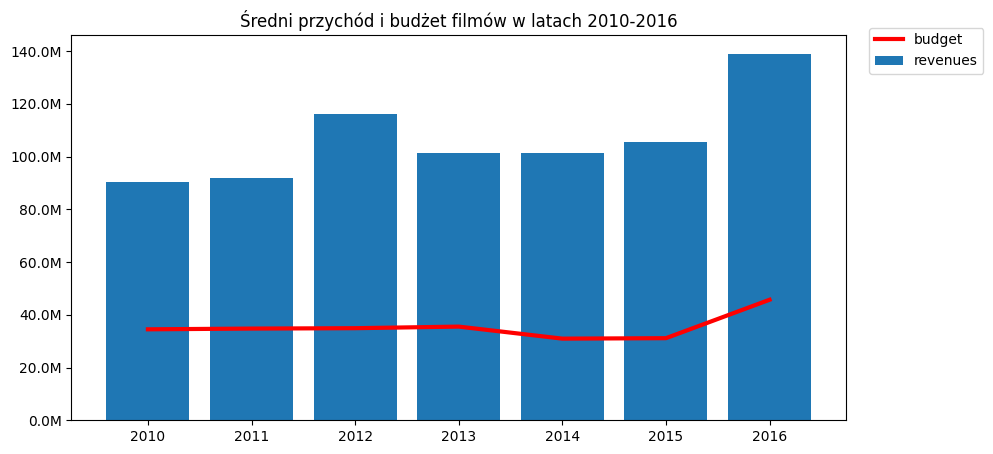

In [106]:
fig, ax = plt.subplots(figsize=(10, 5))
formatter = plt.FuncFormatter(million)

ax.yaxis.set_major_formatter(formatter)
ax.set_title('Średni przychód i budżet filmów w latach 2010-2016') 

ax.bar(ad_2_df.index, ad_2_df['revenue'], label='revenues')
ax.plot(ad_2_df.index, ad_2_df['budget'], color='red', linewidth=3, label='budget')
ax.legend(loc=(1.03, 0.9))
plt.show()